In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

Images shape: (11, 64, 64, 3)
Labels shape: (11,)


(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

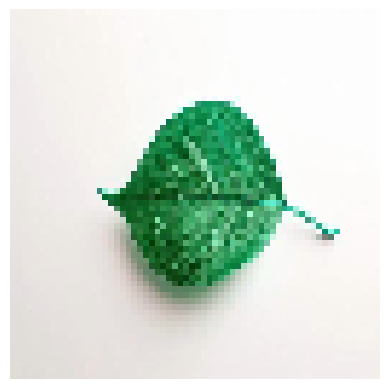

In [2]:
data_path = "plantdataset"   # <-- this is your folder name
categories = ["Class1", "Class2"] # <--this is th sub folder

data = [] #<--empty space to store the images
labels = [] #<--empty space to store the label 0 and 1
img_size = 64

for category in categories:
    folder_path = os.path.join(data_path, category)
    label = categories.index(category)  # Class1 = 0, Class2 = 1
    
    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)
        
        img = cv2.imread(img_path)          # read image
        img = cv2.resize(img, (img_size, img_size))  # resize
        
        data.append(img)     # store image
        labels.append(label) # store label

X = np.array(data) / 255.0
y = np.array(labels)

print("Images shape:", X.shape)
print("Labels shape:", y.shape)

plt.imshow(X[0])
plt.axis("off")

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training images:", len(X_train))
print("Testing images:", len(X_test))

Training images: 8
Testing images: 3


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential()
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)))
model.add(MaxPooling2D((2,2)))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

c:\Users\boyam\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 30752)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,968,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,969,153 (7.51 MB)

 Trainable params: 1,969,153 (7.51 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
model.fit(X_train, y_train, epochs=15, validation_data=(X_test, y_test))

Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5000 - loss: 0.6519 - val_accuracy: 0.6667 - val_loss: 0.6986
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.8750 - loss: 0.3656 - val_accuracy: 0.3333 - val_loss: 2.7704
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.5000 - loss: 1.2871 - val_accuracy: 0.6667 - val_loss: 0.4620
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 1.0000 - loss: 0.1436 - val_accuracy: 0.6667 - val_loss: 0.5910
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.8750 - loss: 0.1419 - val_accuracy: 0.6667 - val_loss: 1.2579
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.7500 - loss: 0.3886 - val_accuracy: 0.6667 - val_loss: 0.7875
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 1.0000 - loss: 0.1017 - val_accuracy: 0.6667 - val_loss: 0.2599
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 1.0000 - loss: 0.0252 - val_accuracy: 1.0000 - val_loss: 0.0

In [7]:
test_img = cv2.imread("test.jpg")
test_img = cv2.resize(test_img, (64,64))
test_img = test_img / 255.0
test_img = np.reshape(test_img, (1,64,64,3))

prediction = model.predict(test_img)

if prediction[0][0] > 0.5:
    print("Predicted: class2")
else:
    print("Predicted: class1")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Predicted: class1
